In [2]:
# 🌾 Crop Yield Prediction - Exploratory Data Analysis

## Setup and Data Loading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')


In [3]:
# Load the data
df = pd.read_csv('../data/raw/FAO_Crop_data.csv')

print("Dataset Overview:")
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nData Types:\n{df.dtypes}")
print(f"\nBasic Statistics:\n{df.describe()}")

Dataset Overview:
Shape: (18000, 12)

Columns: ['year', 'state', 'district', 'rainfall_mm', 'temperature_C', 'humidity_pct', 'soil_N_kg_ha', 'soil_P_kg_ha', 'soil_K_kg_ha', 'soil_pH', 'crop', 'yield_kg_ha']

Data Types:
year               int64
state                str
district             str
rainfall_mm      float64
temperature_C    float64
humidity_pct     float64
soil_N_kg_ha     float64
soil_P_kg_ha     float64
soil_K_kg_ha     float64
soil_pH          float64
crop                 str
yield_kg_ha      float64
dtype: object

Basic Statistics:
               year   rainfall_mm  temperature_C  humidity_pct  soil_N_kg_ha  \
count  18000.000000  17047.000000   17099.000000  17112.000000  17100.000000   
mean    2021.998222    909.876770      27.015538     69.899644     80.721257   
std        1.419545    389.694072       3.993482     14.756503     43.503762   
min     2020.000000    150.000000      10.260000     20.000000      0.000000   
25%     2021.000000    631.000000      24.26000

In [4]:
df

,year,state,district,rainfall_mm,temperature_C,humidity_pct,soil_N_kg_ha,soil_P_kg_ha,soil_K_kg_ha,soil_pH,crop,yield_kg_ha
0,2023,Tamil Nadu,Tamil_D29,1455.8,22.74,89.1,72.6,12.9,35.5,6.79,Jute,NaN
1,2024,Chhattisgarh,Chhattisgarh_D7,1204.5,27.44,70.0,156.2,NaN,30.1,5.69,Pulses,3003.9
2,2022,Kerala,Kerala_D71,1037.2,20.57,81.5,23.5,22.6,NaN,6.40,Cotton,2427.9
3,2024,Tamil Nadu,Tamil_D63,935.3,27.91,NaN,125.2,38.3,44.6,NaN,Jute,3458.1
4,2024,Karnataka,Karnataka_D58,1697.5,34.90,NaN,46.6,8.4,87.0,7.09,Sugarcane,79364.3
...,...,...,...,...,...,...,...,...,...,...,...,...
17995,2020,Assam,Assam_D46,1010.0,27.25,70.1,NaN,40.5,76.3,6.02,Wheat,4644.2
17996,2023,Assam,Assam_D88,745.9,20.10,59.2,153.0,76.7,5.6,6.63,Pulses,2926.2
17997,2024,Jharkhand,Jharkhand_D100,NaN,19.94,39.1,41.7,36.2,11.3,7.90,Cotton,2007.1
17998,2024,Assam,Assam_D43,535.5,26.81,80.8,101.2,NaN,19.7,6.29,Sugarcane,76062.5


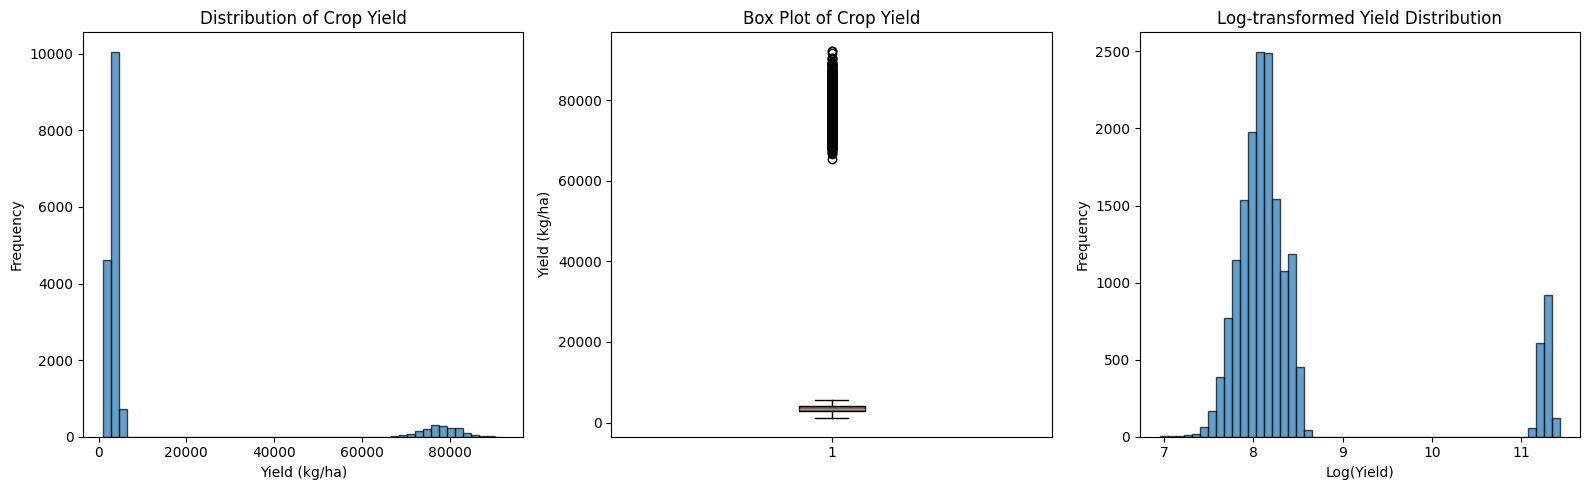


Yield Statistics:
Mean   : 10773.16 kg/ha
Median : 3341.40 kg/ha
Std Dev: 22505.32 kg/ha
Min    : 1043.60 kg/ha
Max    : 92243.50 kg/ha


In [12]:
#Target Variable Analysis - Crop Yield Distribution
# Create figure
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Histogram
axes[0].hist(
    df['yield_kg_ha'].dropna(),
    bins=50,
    edgecolor='black',
    alpha=0.7
)

axes[0].set_title('Distribution of Crop Yield')
axes[0].set_xlabel('Yield (kg/ha)')
axes[0].set_ylabel('Frequency')

# Box Plot
axes[1].boxplot(
    df['yield_kg_ha'].dropna(),
    patch_artist=True
)

axes[1].set_title('Box Plot of Crop Yield')
axes[1].set_ylabel('Yield (kg/ha)')

# Log Transformation
log_yield = np.log1p(df['yield_kg_ha'].dropna())

axes[2].hist(
    log_yield,
    bins=50,
    edgecolor='black',
    alpha=0.7
)

axes[2].set_title('Log-transformed Yield Distribution')
axes[2].set_xlabel('Log(Yield)')
axes[2].set_ylabel('Frequency')

# Layout
plt.tight_layout()

# Save Figure
plt.savefig(
    'visualizations/yield_distribution.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Statistics
print("\nYield Statistics:")
print(f"Mean   : {df['yield_kg_ha'].mean():.2f} kg/ha")
print(f"Median : {df['yield_kg_ha'].median():.2f} kg/ha")
print(f"Std Dev: {df['yield_kg_ha'].std():.2f} kg/ha")
print(f"Min    : {df['yield_kg_ha'].min():.2f} kg/ha")
print(f"Max    : {df['yield_kg_ha'].max():.2f} kg/ha")

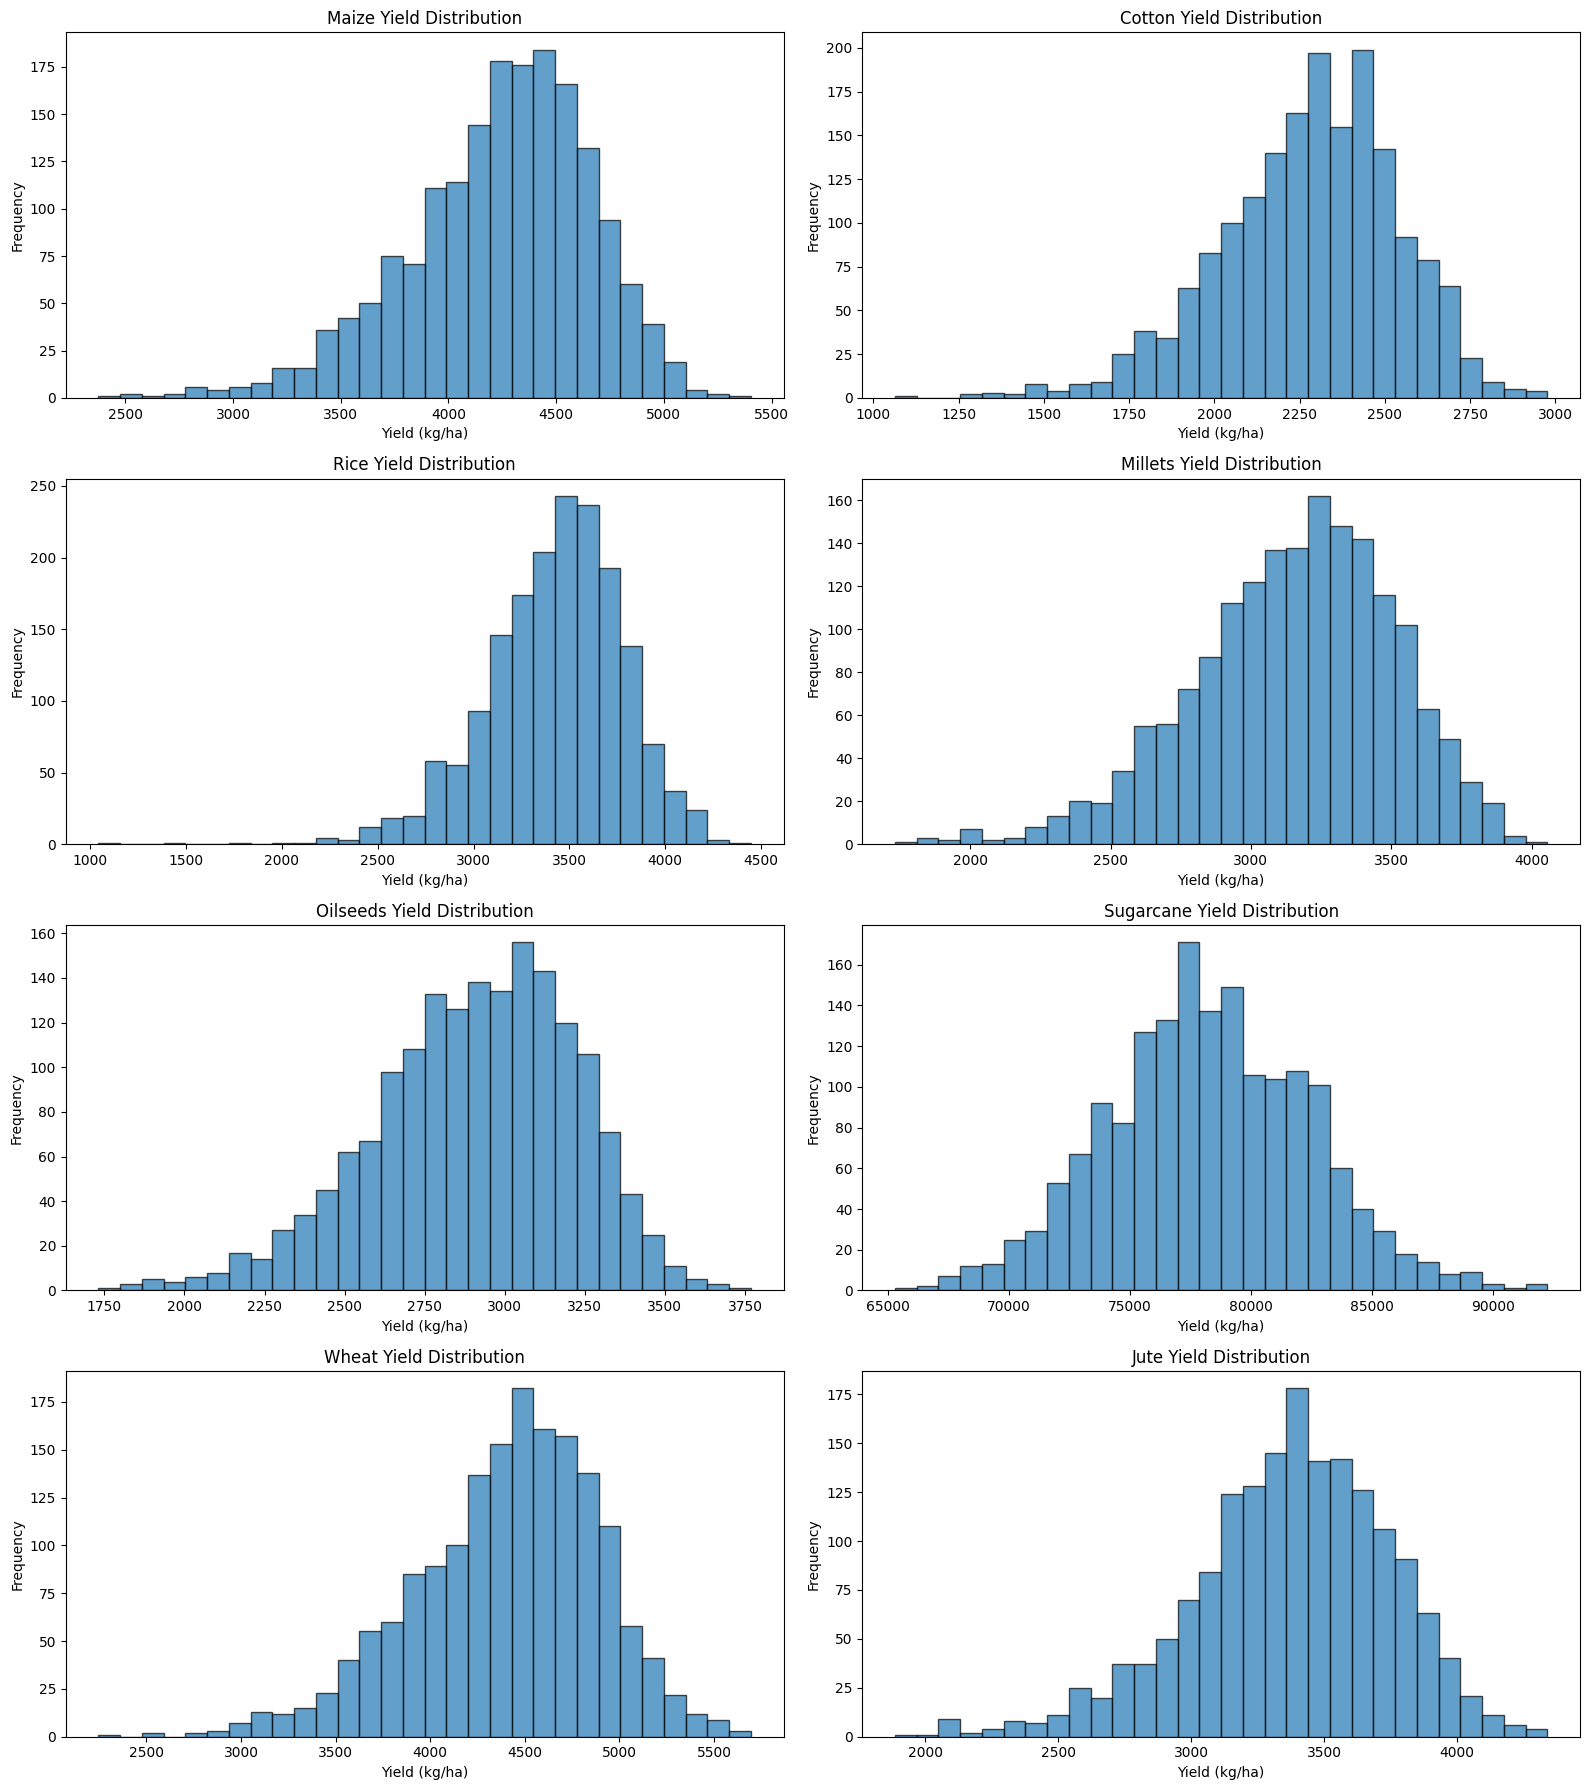


Top 10 Crops by Average Yield:
                   mean    median          std
crop                                          
Sugarcane  78251.497887  78184.80  4180.699454
Wheat       4406.962367   4459.95   491.397065
Maize       4240.188750   4292.45   427.714591
Rice        3427.376007   3468.60   357.250063
Jute        3369.329787   3400.50   376.681186
Groundnut   3271.378528   3317.50   377.586492
Millets     3153.256199   3183.80   359.064546
Oilseeds    2905.839207   2936.25   315.131321
Pulses      2658.364093   2698.60   312.864798
Cotton      2279.873062   2303.20   261.144352


In [18]:
# =========================================================
# Crop-wise Yield Analysis
# =========================================================

# Group statistics
crop_yield = (
    df.groupby('crop')['yield_kg_ha']
    .agg(['mean', 'median', 'std'])
    .sort_values('mean', ascending=False)
)

# =========================================================
# Top 10 Crops by Yield
# =========================================================

fig = px.bar(
    crop_yield.head(10),
    x=crop_yield.head(10).index,
    y='mean',
    error_y='std',
    title='Top 10 Crops by Average Yield',
    labels={
        'x': 'Crop Type',
        'mean': 'Average Yield (kg/ha)'
    }
)

fig.update_layout(
    xaxis_tickangle=-45
)

fig.show()

# Save interactive chart
fig.write_html(
    'visualizations/crop_yield_comparison.png'
)

# =========================================================
# Detailed Crop Distribution Analysis
# =========================================================

top_crops = df['crop'].value_counts().head(8).index

fig, axes = plt.subplots(4, 2, figsize=(16, 18))

axes = axes.flatten()

for i, crop in enumerate(top_crops):

    crop_data = (
        df[df['crop'] == crop]['yield_kg_ha']
        .dropna()
    )

    axes[i].hist(
        crop_data,
        bins=30,
        edgecolor='black',
        alpha=0.7
    )

    axes[i].set_title(f'{crop} Yield Distribution')

    axes[i].set_xlabel('Yield (kg/ha)')

    axes[i].set_ylabel('Frequency')

# Remove unused plots if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.savefig(
    'visualizations/crop_wise_distributions.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# =========================================================
# Print Top Crop Statistics
# =========================================================

print("\nTop 10 Crops by Average Yield:")

print(crop_yield.head(10))

In [17]:
# =========================================================
# State-wise Analysis
# =========================================================

# Average yield by state
state_yield = (
    df.groupby('state')['yield_kg_ha']
    .mean()
    .sort_values(ascending=False)
)

# =========================================================
# State-wise Yield Bar Chart
# =========================================================

fig = px.bar(
    x=state_yield.index,
    y=state_yield.values,
    title='Average Crop Yield by State',
    labels={
        'x': 'State',
        'y': 'Average Yield (kg/ha)'
    },
    color=state_yield.values,
    color_continuous_scale='Viridis'
)

fig.update_layout(
    xaxis_tickangle=-45,
    width=1200,
    height=600
)

fig.show()

# Save interactive visualization
fig.write_html(
    'visualizations/state_yield_analysis.png'
)

# =========================================================
# State-Crop Distribution Matrix
# =========================================================

state_crop_matrix = pd.crosstab(
    df['state'],
    df['crop']
)

fig = px.imshow(
    state_crop_matrix,
    aspect='auto',
    color_continuous_scale='Blues',
    title='State-Crop Distribution Matrix',
    labels={
        'x': 'Crop Type',
        'y': 'State',
        'color': 'Count'
    }
)

fig.update_layout(
    width=1200,
    height=700
)

fig.show()

# Save heatmap
fig.write_html(
    'visualizations/state_crop_matrix.png'
)

# =========================================================
# Print Top States
# =========================================================

print("\nTop 10 States by Average Yield:\n")

print(state_yield.head(10))


Top 10 States by Average Yield:

state
Uttar Pradesh     11555.352095
Andhra Pradesh    11550.093293
Punjab            11424.604946
Jharkhand         11283.930776
Tamil Nadu        11180.366126
Bihar             11039.431579
Odisha            10984.967633
Haryana           10865.985283
Karnataka         10829.792081
Telangana         10803.389925
Name: yield_kg_ha, dtype: float64


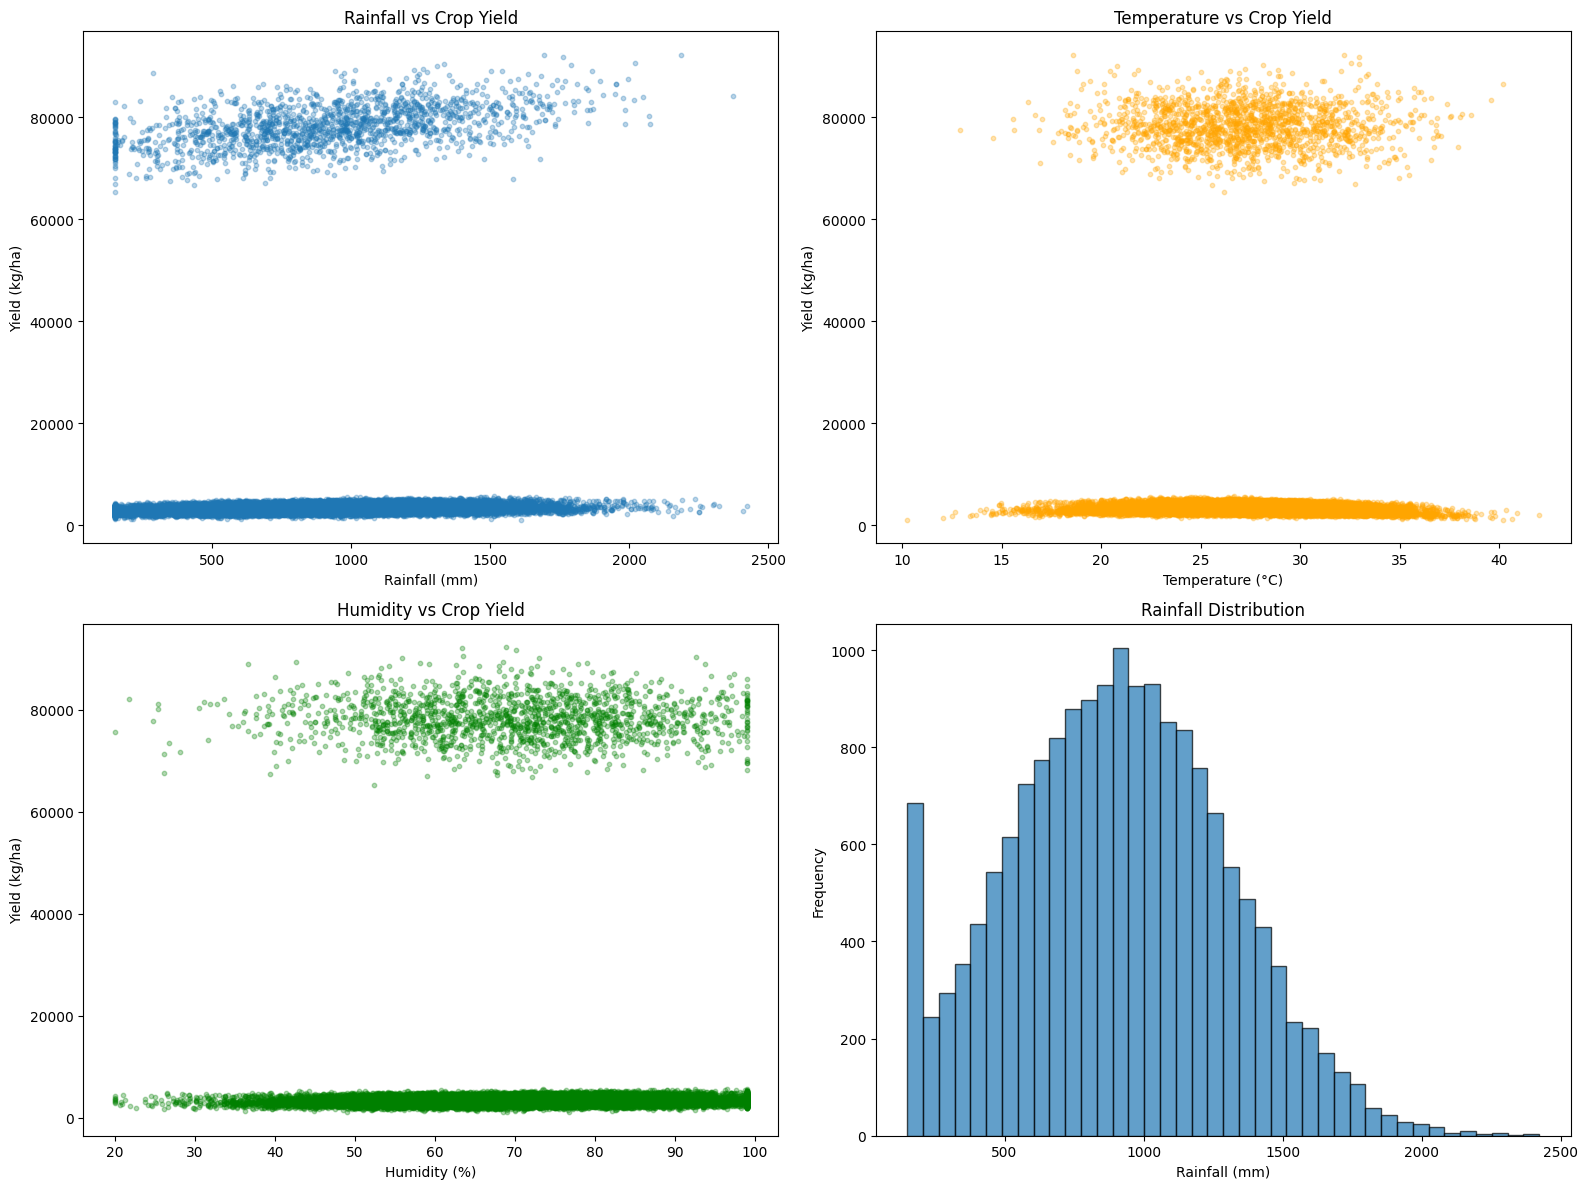

In [16]:
# =========================================================
# Climate Factors Analysis
# =========================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# =========================================================
# Rainfall vs Yield
# =========================================================

axes[0, 0].scatter(
    df['rainfall_mm'],
    df['yield_kg_ha'],
    alpha=0.3,
    s=10
)

axes[0, 0].set_xlabel('Rainfall (mm)')
axes[0, 0].set_ylabel('Yield (kg/ha)')
axes[0, 0].set_title('Rainfall vs Crop Yield')

# =========================================================
# Temperature vs Yield
# =========================================================

axes[0, 1].scatter(
    df['temperature_C'],
    df['yield_kg_ha'],
    alpha=0.3,
    s=10,
    color='orange'
)

axes[0, 1].set_xlabel('Temperature (°C)')
axes[0, 1].set_ylabel('Yield (kg/ha)')
axes[0, 1].set_title('Temperature vs Crop Yield')

# =========================================================
# Humidity vs Yield
# =========================================================

axes[1, 0].scatter(
    df['humidity_pct'],
    df['yield_kg_ha'],
    alpha=0.3,
    s=10,
    color='green'
)

axes[1, 0].set_xlabel('Humidity (%)')
axes[1, 0].set_ylabel('Yield (kg/ha)')
axes[1, 0].set_title('Humidity vs Crop Yield')

# =========================================================
# Rainfall Distribution
# =========================================================

axes[1, 1].hist(
    df['rainfall_mm'].dropna(),
    bins=40,
    edgecolor='black',
    alpha=0.7
)

axes[1, 1].set_title('Rainfall Distribution')
axes[1, 1].set_xlabel('Rainfall (mm)')
axes[1, 1].set_ylabel('Frequency')

# =========================================================
# Save Figure
# =========================================================

plt.tight_layout()

plt.savefig(
    'visualizations/climate_yield_relationships.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# =========================================================
# 3D Climate Visualization
# =========================================================

fig_3d = px.scatter_3d(
    df,
    x='rainfall_mm',
    y='temperature_C',
    z='yield_kg_ha',
    color='crop',
    opacity=0.7,
    title='3D Visualization: Rainfall, Temperature, and Yield'
)

fig_3d.update_layout(
    width=1000,
    height=700
)

fig_3d.show()

# Save 3D plot
fig_3d.write_html(
    'visualizations/climate_3d_analysis.png'
)

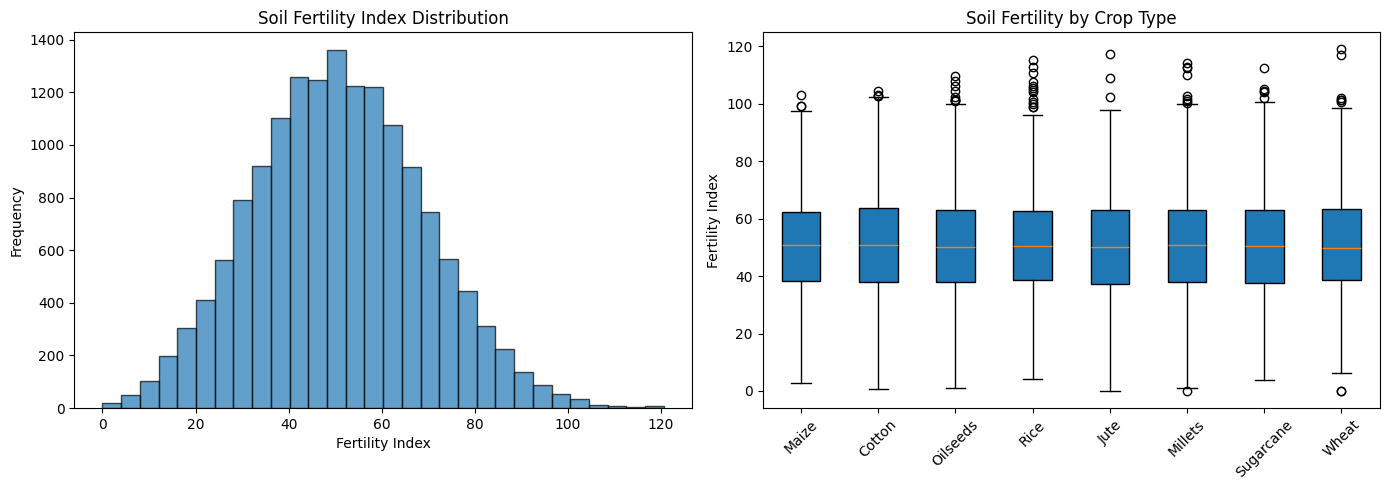


Soil Feature Correlations with Yield:

soil_P_kg_ha   -0.006835
soil_pH        -0.006251
soil_N_kg_ha    0.003995
soil_K_kg_ha    0.010339
yield_kg_ha     1.000000
Name: yield_kg_ha, dtype: float64


In [20]:
# =========================================================
# Soil Nutrient Analysis
# =========================================================

soil_features = [
    'soil_N_kg_ha',
    'soil_P_kg_ha',
    'soil_K_kg_ha',
    'soil_pH'
]

# =========================================================
# Correlation with Yield
# =========================================================

soil_corr = (
    df[soil_features + ['yield_kg_ha']]
    .corr()['yield_kg_ha']
    .sort_values()
)

fig = px.bar(
    x=soil_corr.index[:-1],
    y=soil_corr.values[:-1],
    title='Soil Features Correlation with Yield',
    labels={
        'x': 'Soil Feature',
        'y': 'Correlation Coefficient'
    },
    color=soil_corr.values[:-1],
    color_continuous_scale='Viridis'
)

fig.show()

# Save interactive plot
fig.write_html(
    'visualizations/soil_feature_correlation.png'
)

# =========================================================
# Soil Fertility Index
# =========================================================

df['soil_fertility'] = (
    df['soil_N_kg_ha'] +
    df['soil_P_kg_ha'] +
    df['soil_K_kg_ha']
) / 3

# =========================================================
# Distribution + Crop-wise Analysis
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---------------------------------------------------------
# Fertility Distribution
# ---------------------------------------------------------

axes[0].hist(
    df['soil_fertility'].dropna(),
    bins=30,
    edgecolor='black',
    alpha=0.7
)

axes[0].set_title('Soil Fertility Index Distribution')

axes[0].set_xlabel('Fertility Index')

axes[0].set_ylabel('Frequency')

# ---------------------------------------------------------
# Box Plot by Crop
# ---------------------------------------------------------

df_clean = df.dropna(
    subset=['crop', 'soil_fertility']
)

top_crops = (
    df_clean['crop']
    .value_counts()
    .head(8)
    .index
)

box_data = [
    df_clean[
        df_clean['crop'] == crop
    ]['soil_fertility'].values

    for crop in top_crops
]

axes[1].boxplot(
    box_data,
    labels=top_crops,
    patch_artist=True
)

axes[1].set_title(
    'Soil Fertility by Crop Type'
)

axes[1].set_ylabel('Fertility Index')

axes[1].tick_params(
    axis='x',
    rotation=45
)

# =========================================================
# Save Figure
# =========================================================

plt.tight_layout()

plt.savefig(
    'visualizations/soil_analysis.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# =========================================================
# Print Soil Correlation Values
# =========================================================

print("\nSoil Feature Correlations with Yield:\n")

print(soil_corr)

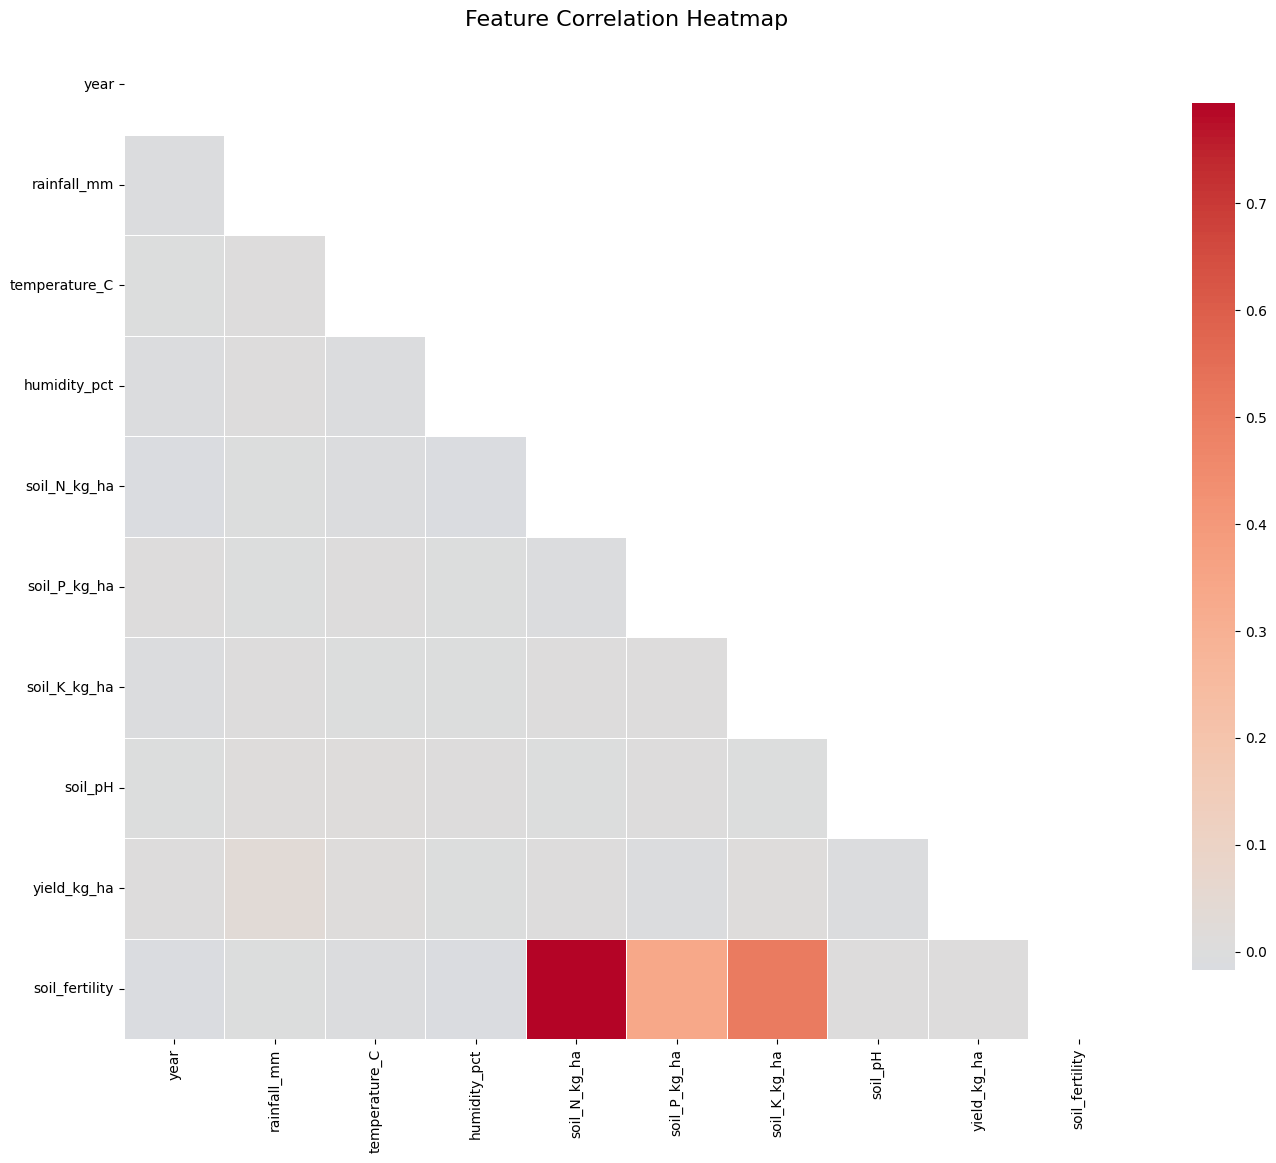


Top Features Correlated with Yield:
yield_kg_ha       1.000000
rainfall_mm       0.031283
soil_K_kg_ha      0.010339
temperature_C     0.010097
year              0.005618
soil_N_kg_ha      0.003995
soil_fertility    0.003205
humidity_pct      0.000683
soil_pH          -0.006251
soil_P_kg_ha     -0.006835
Name: yield_kg_ha, dtype: float64


In [21]:
# =========================================================
# Correlation Matrix and Heatmap
# =========================================================

# Numerical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Correlation matrix
correlation_matrix = df[numeric_cols].corr()

# =========================================================
# Heatmap
# =========================================================

plt.figure(figsize=(14, 12))

mask = np.triu(
    np.ones_like(
        correlation_matrix,
        dtype=bool
    )
)

sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=False,
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title(
    'Feature Correlation Heatmap',
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    'visualizations/correlation_heatmap.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# =========================================================
# Correlation with Yield
# =========================================================

yield_corr = (
    correlation_matrix['yield_kg_ha']
    .sort_values(ascending=False)
)

print("\nTop Features Correlated with Yield:")

print(yield_corr)

# =========================================================
# Time Series Analysis
# =========================================================

yearly_trend = (
    df.groupby('year')['yield_kg_ha']
    .mean()
    .reset_index()
)

fig = px.line(
    yearly_trend,
    x='year',
    y='yield_kg_ha',
    title='Crop Yield Trend Over Years',
    markers=True
)

fig.update_layout(
    xaxis_title='Year',
    yaxis_title='Average Yield (kg/ha)'
)

fig.show()

# Save interactive plot
fig.write_html(
    'visualizations/yearly_yield_trend.png'
)

In [23]:
# =========================================================
# Time Series Analysis
# =========================================================

# ---------------------------------------------------------
# Overall Yearly Trend
# ---------------------------------------------------------

yearly_trend = (
    df.groupby('year')['yield_kg_ha']
    .mean()
    .reset_index()
)

fig = px.line(
    yearly_trend,
    x='year',
    y='yield_kg_ha',
    title='Crop Yield Trend Over Years',
    markers=True
)

fig.update_layout(
    xaxis_title='Year',
    yaxis_title='Average Yield (kg/ha)'
)

fig.show()

# Save plot
fig.write_html(
    'visualizations/yearly_yield_trend.png'
)

# ---------------------------------------------------------
# State-wise Yearly Trends
# ---------------------------------------------------------

top_states = (
    df['state']
    .value_counts()
    .head(5)
    .index
)

state_yearly = (
    df[df['state'].isin(top_states)]
    .groupby(['year', 'state'])['yield_kg_ha']
    .mean()
    .reset_index()
)

fig = px.line(
    state_yearly,
    x='year',
    y='yield_kg_ha',
    color='state',
    title='Yearly Yield Trends by State',
    markers=True
)

fig.update_layout(
    xaxis_title='Year',
    yaxis_title='Average Yield (kg/ha)'
)

fig.show()

# Save state-wise trends
fig.write_html(
    'visualizations/state_yearly_trends.png'
)

In [25]:
# =========================================================
# Feature Importance using Random Forest
# =========================================================

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

# ---------------------------------------------------------
# Copy Dataset
# ---------------------------------------------------------

df_imp = df.copy()

# ---------------------------------------------------------
# Encode Categorical Features
# ---------------------------------------------------------

categorical_cols = [
    'state',
    'district',
    'crop'
]

for col in categorical_cols:

    if col in df_imp.columns:

        encoder = LabelEncoder()

        df_imp[col] = encoder.fit_transform(
            df_imp[col].astype(str)
        )

# ---------------------------------------------------------
# Remove Null Target Rows
# ---------------------------------------------------------

df_imp = df_imp.dropna(
    subset=['yield_kg_ha']
)

# ---------------------------------------------------------
# Feature Selection
# ---------------------------------------------------------

feature_cols = [

    col for col in df_imp.columns

    if (
        col != 'yield_kg_ha'
        and df_imp[col].dtype in ['int64', 'float64']
    )
]

X_imp = df_imp[feature_cols]

y_imp = df_imp['yield_kg_ha']

# ---------------------------------------------------------
# Handle NaN Values
# ---------------------------------------------------------

X_imp = X_imp.fillna(
    X_imp.median()
)

# ---------------------------------------------------------
# Random Forest Model
# ---------------------------------------------------------

rf_imp = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_imp.fit(X_imp, y_imp)

# ---------------------------------------------------------
# Feature Importance DataFrame
# ---------------------------------------------------------

importance_df = pd.DataFrame({

    'feature': feature_cols,

    'importance': rf_imp.feature_importances_

}).sort_values(
    'importance',
    ascending=False
)

# ---------------------------------------------------------
# Plot Feature Importance
# ---------------------------------------------------------

fig = px.bar(
    importance_df.head(15),
    x='importance',
    y='feature',
    orientation='h',
    title='Initial Feature Importance (Random Forest)',
    color='importance',
    color_continuous_scale='Viridis'
)

fig.update_layout(
    yaxis={'categoryorder': 'total ascending'}
)

fig.show()

# Save interactive plot
fig.write_html(
    'visualizations/feature_importance.png'
)

# ---------------------------------------------------------
# Print Top Features
# ---------------------------------------------------------

print("\nTop 10 Most Important Features:\n")

print(importance_df.head(10))


Top 10 Most Important Features:

           feature  importance
10            crop    0.996313
3      rainfall_mm    0.001138
11  soil_fertility    0.000404
4    temperature_C    0.000373
6     soil_N_kg_ha    0.000333
9          soil_pH    0.000288
5     humidity_pct    0.000282
8     soil_K_kg_ha    0.000254
7     soil_P_kg_ha    0.000237
2         district    0.000208


In [26]:
# =========================================================
# Advanced Visualizations
# =========================================================

# ---------------------------------------------------------
# Parallel Coordinates Plot
# ---------------------------------------------------------

parallel_features = [
    'rainfall_mm',
    'temperature_C',
    'humidity_pct',
    'soil_N_kg_ha',
    'soil_P_kg_ha',
    'soil_K_kg_ha',
    'yield_kg_ha'
]

fig = px.parallel_coordinates(
    df.dropna(subset=parallel_features),
    dimensions=parallel_features,
    color='yield_kg_ha',
    color_continuous_scale=px.colors.diverging.Tealrose,
    title='Parallel Coordinates Plot - Multidimensional Analysis'
)

fig.show()

# Save plot
fig.write_html(
    'visualizations/parallel_coordinates.png'
)

# ---------------------------------------------------------
# Violin Plot
# ---------------------------------------------------------

top_10_crops = (
    df['crop']
    .value_counts()
    .head(10)
    .index
)

df_top_crops = (
    df[df['crop'].isin(top_10_crops)]
)

fig = px.violin(
    df_top_crops,
    x='crop',
    y='yield_kg_ha',
    box=True,
    points='all',
    title='Yield Distribution by Crop Type (Violin Plot)'
)

fig.update_layout(
    xaxis_tickangle=-45
)

fig.show()

# Save violin plot
fig.write_html(
    'visualizations/crop_violin_plot.png'
)

# ---------------------------------------------------------
# Radar Chart
# ---------------------------------------------------------

selected_crop = (
    df['crop']
    .value_counts()
    .index[0]
)

radar_features = [
    'rainfall_mm',
    'temperature_C',
    'humidity_pct',
    'soil_N_kg_ha',
    'soil_P_kg_ha',
    'soil_K_kg_ha',
    'soil_pH',
    'yield_kg_ha'
]

crop_data = (
    df[df['crop'] == selected_crop][radar_features]
    .mean()
)

fig = go.Figure()

fig.add_trace(
    go.Scatterpolar(
        r=crop_data.values,
        theta=radar_features,
        fill='toself',
        name=selected_crop
    )
)

fig.update_layout(
    title=f'{selected_crop} - Average Characteristics (Radar Chart)',
    polar=dict(
        radialaxis=dict(
            visible=True
        )
    )
)

fig.show()

# Save radar chart
fig.write_html(
    'visualizations/crop_radar_chart.png'
)

In [27]:
# =========================================================
# Summary Statistics and Insights
# =========================================================

print("=" * 60)
print("KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS")
print("=" * 60)

# ---------------------------------------------------------
# Data Overview
# ---------------------------------------------------------

print("\n1. Data Overview:")

print(f"   • Total Samples      : {len(df)}")

print(f"   • Unique Crops       : {df['crop'].nunique()}")

print(f"   • Unique States      : {df['state'].nunique()}")

print(
    f"   • Year Range         : "
    f"{df['year'].min()} to {df['year'].max()}"
)

# ---------------------------------------------------------
# Top Performing Crops
# ---------------------------------------------------------

print("\n2. Top Performing Crops:")

for crop in crop_yield.head(3).index:

    print(
        f"   • {crop}: "
        f"{crop_yield.loc[crop, 'mean']:.0f} kg/ha"
    )

# ---------------------------------------------------------
# Best Performing States
# ---------------------------------------------------------

print("\n3. Best Performing States:")

for state in state_yield.head(3).index:

    print(
        f"   • {state}: "
        f"{state_yield[state]:.0f} kg/ha"
    )

# ---------------------------------------------------------
# Top Correlated Features
# ---------------------------------------------------------

print("\n4. Key Correlations with Yield:")

top_corr_features = (
    yield_corr.drop('yield_kg_ha')
    .abs()
    .sort_values(ascending=False)
)

for feature, corr in top_corr_features.head(3).items():

    print(
        f"   • {feature}: "
        f"{corr:.3f}"
    )

# ---------------------------------------------------------
# Modeling Recommendations
# ---------------------------------------------------------

print("\n5. Recommendations for Modeling:")

print(
    "   • Use Random Forest feature importance "
    "for feature selection"
)

print(
    "   • Consider logarithmic transformation "
    "for skewed yield distributions"
)

print(
    "   • Include interaction terms "
    "(temperature × rainfall)"
)

print(
    "   • Create region-aware agro-climatic features"
)

print(
    "   • Use ensemble and hybrid deep learning models "
    "for better nonlinear prediction"
)

# ---------------------------------------------------------
# Final Conclusion
# ---------------------------------------------------------

print("\n6. Final EDA Conclusion:")

print(
    "   • Climate, soil nutrients, and regional "
    "factors strongly influence crop yield."
)

print(
    "   • Significant nonlinear relationships exist "
    "between environmental variables and yield."
)

print(
    "   • Random Forest and Hybrid Deep Learning "
    "approaches are suitable for this dataset."
)

print("=" * 60)
print("EDA COMPLETED SUCCESSFULLY")
print("=" * 60)

KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS

1. Data Overview:
   • Total Samples      : 18000
   • Unique Crops       : 10
   • Unique States      : 16
   • Year Range         : 2020 to 2024

2. Top Performing Crops:
   • Sugarcane: 78251 kg/ha
   • Wheat: 4407 kg/ha
   • Maize: 4240 kg/ha

3. Best Performing States:
   • Uttar Pradesh: 11555 kg/ha
   • Andhra Pradesh: 11550 kg/ha
   • Punjab: 11425 kg/ha

4. Key Correlations with Yield:
   • rainfall_mm: 0.031
   • soil_K_kg_ha: 0.010
   • temperature_C: 0.010

5. Recommendations for Modeling:
   • Use Random Forest feature importance for feature selection
   • Consider logarithmic transformation for skewed yield distributions
   • Include interaction terms (temperature × rainfall)
   • Create region-aware agro-climatic features
   • Use ensemble and hybrid deep learning models for better nonlinear prediction

6. Final EDA Conclusion:
   • Climate, soil nutrients, and regional factors strongly influence crop yield.
   • Significant n